In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import krippendorff
from irrCAC.raw import CAC

# Download dataset - STEXPL

In [ ]:
df = pd.read_csv(
    "data/datasets/MQI_STEXPL_dataset.csv",
    sep=",",
    dtype={"OBSID": "string", "RATERID": "string", "NCTETID":"string", "full_chapter_text":"string"},
    encoding="utf-8"
)
df.head()

,NCTETID,OBSID,CHAPNUM,DISTRICT,SCHOOLYEAR_SP,Rater 1,Rater 10,Rater 11,Rater 12,Rater 13,...,Rater 59,Rater 6,Rater 60,Rater 61,Rater 62,Rater 63,Rater 7,Rater 8,Rater 9,full_text
0,11001,128,1,11,2011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"teacher: Can someone go – Student B, go find S..."
1,11001,128,2,11,2011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,teacher: Okay. So Student B is listing the pa...
2,11001,128,3,11,2011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student: [Inaudible].\nteacher: All right. I'...
3,11001,128,4,11,2011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,teacher: How are you going to show your work? ...
4,11001,128,5,11,2011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,teacher: Do you want to do it a third time and...


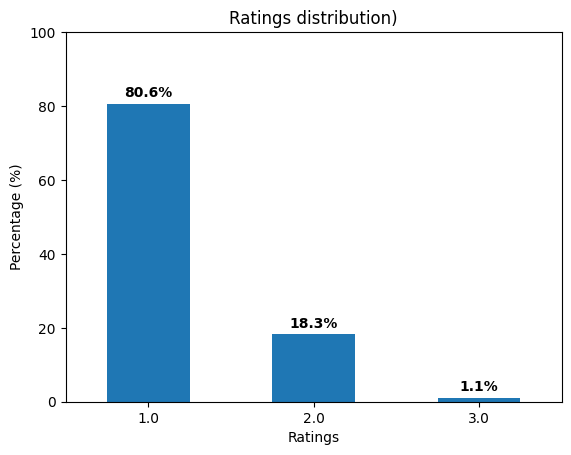

In [ ]:
matrix = df.drop(columns=["NCTETID", "OBSID", "CHAPNUM", "DISTRICT", "SCHOOLYEAR_SP", "full_text"])

# Convert to long format for counting all ratings
ratings = pd.Series(matrix.values.ravel())
ratings = ratings.dropna() # remove NaN values

proportions = ratings.value_counts(normalize=True).sort_index() * 100  # en pourcentage

# Bar chart of ratings distribution
ax = proportions.plot(kind="bar")
plt.title("Ratings distribution)")
plt.xlabel("Ratings")
plt.xticks(rotation=0)
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
# Display the percentage on top of each bar
for i, (cat, pct) in enumerate(proportions.items()):
    ax.text(i, pct + 1, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.show()

# Krippenddorf's alpha and Gwet's AC2 on all dataset

In [ ]:
matrix = matrix.apply(pd.to_numeric, errors="coerce")

alpha = krippendorff.alpha(reliability_data=matrix.to_numpy().T, level_of_measurement='ordinal', value_domain=[1,2,3])
print("krippendorff's alpha:", alpha)

krippendorff's alpha: 0.3928576999458774


In [ ]:
matrix_copy = matrix.copy()
cac = CAC(matrix_copy, weights='quadratic')   # 'quadratic' because a discrepency 1-3 is worse than 1-2
res = cac.gwet()

print(res["est"]["coefficient_name"], ": ", res["est"]["coefficient_value"])
print("IC95%:", res["est"]["confidence_interval"])
print("p-value:", res["est"]["p_value"])


AC2 :  0.91772
IC95%: (0.91349, 0.92195)
p-value: 0.0


/home/mayalen/Desktop/NTCE/.venv/lib/python3.11/site-packages/irrCAC/raw.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.ratings.replace(to_replace="", value=np.nan, inplace=True)


# Balanced subsample

In [ ]:
# --- Precompute per-item rating counts (how many 1/2/3 each item has) ---
counts_1 = (matrix == 1).sum(axis=1)
counts_2 = (matrix == 2).sum(axis=1)
counts_3 = (matrix == 3).sum(axis=1)

item_counts = pd.DataFrame({
    "c1": counts_1,
    "c2": counts_2,
    "c3": counts_3
})

# Ignore items with zero ratings entirely (all NaN) if any
item_counts = item_counts[(item_counts.sum(axis=1) > 0)]

# --- Initialize selection: keep all items that have at least one "3" ---
selected = set(item_counts.index[item_counts["c3"] > 0])
remaining = set(item_counts.index) - selected

# --- Helper: compute proportions and imbalance score ---
def proportions_and_score(sel_idx):
    if not sel_idx:
        return (np.array([0.0, 0.0, 0.0]), 1.0)
    sel_df = item_counts.loc[list(sel_idx)]
    total = sel_df[["c1","c2","c3"]].sum().to_numpy(dtype=float)
    tot_sum = total.sum()
    if tot_sum == 0:
        return (np.array([0.0, 0.0, 0.0]), 1.0)
    props = total / tot_sum
    # Score = max absolute deviation from the ideal 1/3
    score = np.max(np.abs(props - 1.0/3.0))
    return props, score

# Current proportions/score after step 1
props, score = proportions_and_score(selected)

# --- Greedy loop: add one item at a time if it reduces imbalance ---
tolerance = 0.05          # ±5% around 1/3
max_iter = 10000         # safety cap for very large sets

def best_candidate(current_sel, candidates, current_score):
    """
    Among candidates, return the item that yields the smallest score
    (max deviation from 1/3) when added. Also return that new score.
    """
    best_it = None
    best_score = current_score
    # Pre-sum current counts for speed
    sel_df = item_counts.loc[list(current_sel)]
    cur_tot = sel_df[["c1","c2","c3"]].sum().to_numpy(dtype=float)
    cur_sum = cur_tot.sum()

    # Vectorized trick: evaluate in blocks if needed (simple loop is fine too)
    for it in candidates:
        add = item_counts.loc[it, ["c1","c2","c3"]].to_numpy(dtype=float)
        new_tot = cur_tot + add
        new_sum = cur_sum + add.sum()
        if new_sum == 0:
            continue
        new_props = new_tot / new_sum
        new_score = np.max(np.abs(new_props - 1.0/3.0))
        if new_score < best_score - 1e-12:  # strict improvement
            best_score = new_score
            best_it = it
    return best_it, best_score

iter_count = 0
while score > tolerance and remaining and iter_count < max_iter:
    cand, new_score = best_candidate(selected, remaining, score)
    # Stop if no candidate improves the score (cannot reach tolerance)
    if cand is None or new_score >= score:
        break
    # Accept the candidate
    selected.add(cand)
    remaining.remove(cand)
    score = new_score
    iter_count += 1

# --- Final report ---
final_props, final_score = proportions_and_score(selected)
print("Selected items:", len(selected))
print("Final proportions (1,2,3):", np.round(final_props, 4))
print("Max abs deviation from 1/3:", np.round(final_score, 4))
print(f"Target tolerance: ±{tolerance:.2f}")

balanced_df = df.loc[list(selected)]


Selected items: 329
Final proportions (1,2,3): [0.3315 0.2861 0.3824]
Max abs deviation from 1/3: 0.0491
Target tolerance: ±0.05


In [ ]:
# --- Prepare annotation matrix (items x raters) ---
matrix = (
    df.drop(columns=["NCTETID", "OBSID", "CHAPNUM", "DISTRICT", "SCHOOLYEAR_SP", "full_text"])
      .apply(pd.to_numeric, errors="coerce")
)

# --- Per-item counts of 1/2/3 ---
item_counts = pd.DataFrame({
    "c1": (matrix == 1).sum(axis=1),
    "c2": (matrix == 2).sum(axis=1),
    "c3": (matrix == 3).sum(axis=1),
})
item_counts = item_counts[item_counts.sum(axis=1) > 0]  # keep items with at least one rating

# --- Step 1: select all items that have at least one 3 (fix #3) ---
sel = set(item_counts.index[item_counts["c3"] > 0])

def totals(idx):
    if not idx:
        return np.array([0,0,0], dtype=int)
    s = item_counts.loc[list(idx), ["c1","c2","c3"]].sum().to_numpy(dtype=int)
    return s

c1, c2, c3 = totals(sel)
print(f"[init] #1={c1}  #2={c2}  #3={c3}")

# Remaining pool: items WITHOUT any 3s (so adding them won't change #3)
pool = item_counts[(item_counts["c3"] == 0)].copy()

# Split pool into helpful buckets
only1   = pool[(pool["c1"] > 0) & (pool["c2"] == 0)]           # boosts #1 only
only2   = pool[(pool["c2"] > 0) & (pool["c1"] == 0)]           # boosts #2 only
mix12   = pool[(pool["c1"] > 0) & (pool["c2"] > 0)]            # boosts both

tol = 0.01  # ±5%

# --- Step 2: fill #1 up to ~ #3 (±5%), prioritizing 1-only ---
target_min_1 = int(np.floor(c3 * (1 - tol)))
if c1 < target_min_1:
    # add from 1-only first
    only1_sorted = only1.sort_values(by="c1", ascending=False)
    for it, row in only1_sorted.iterrows():
        if c1 >= target_min_1:
            break
        sel.add(it); c1 += int(row["c1"])
    # if still short, take mixed (prefer items with high c1 / low c2)
    if c1 < target_min_1 and not mix12.empty:
        mix12["score1"] = mix12["c1"] / (mix12["c2"] + 1e-9)
        for it, row in mix12.sort_values("score1", ascending=False).iterrows():
            if it in sel: 
                continue
            if c1 >= target_min_1:
                break
            sel.add(it); c1 += int(row["c1"]); c2 += int(row["c2"])

# --- Step 3: fill #2 up to ~ #3 (±5%), prioritizing 2-only ---
target_min_2 = int(np.floor(c3 * (1 - tol)))
if c2 < target_min_2:
    # add from 2-only first
    only2_sorted = only2.sort_values(by="c2", ascending=False)
    for it, row in only2_sorted.iterrows():
        if c2 >= target_min_2:
            break
        if it in sel:
            continue
        sel.add(it); c2 += int(row["c2"])
    # if still short, take mixed (prefer items with high c2 / low c1)
    if c2 < target_min_2 and not mix12.empty:
        mix12["score2"] = mix12["c2"] / (mix12["c1"] + 1e-9)
        for it, row in mix12.sort_values("score2", ascending=False).iterrows():
            if it in sel:
                continue
            if c2 >= target_min_2:
                break
            sel.add(it); c1 += int(row["c1"]); c2 += int(row["c2"])

# --- Final check: are #1 and #2 within ±5% of #3? ---
def within_tol(c1, c2, c3, tol=0.05):
    denom = max(1, c3)
    return (abs(c1 - c3) <= tol * denom) and (abs(c2 - c3) <= tol * denom)

print(f"[final] #1={c1}  #2={c2}  #3={c3}  -> within ±{int(tol*100)}%? {within_tol(c1,c2,c3,tol)}")

balanced_df = df.loc[list(sel)]


[init] #1=91  #2=138  #3=278
[final] #1=275  #2=275  #3=278  -> within ±1%? False


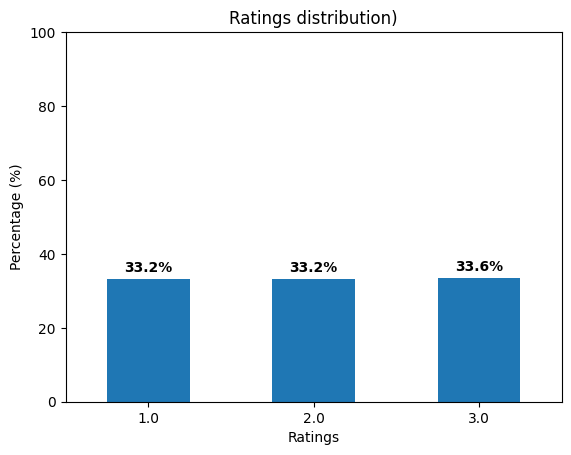

In [ ]:
matrix_balanced = balanced_df.drop(columns=["NCTETID", "OBSID", "CHAPNUM", "DISTRICT", "SCHOOLYEAR_SP", "full_text"])

# Convert to long format for counting all ratings
ratings = pd.Series(matrix_balanced.values.ravel())
ratings = ratings.dropna() # remove NaN values

proportions = ratings.value_counts(normalize=True).sort_index() * 100  # en pourcentage

# Bar chart of ratings distribution
ax = proportions.plot(kind="bar")
plt.title("Ratings distribution)")
plt.xlabel("Ratings")
plt.xticks(rotation=0)
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
# Display the percentage on top of each bar
for i, (cat, pct) in enumerate(proportions.items()):
    ax.text(i, pct + 1, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.show()

In [ ]:
matrix_balanced = matrix_balanced.apply(pd.to_numeric, errors="coerce")

alpha = krippendorff.alpha(reliability_data=matrix_balanced.to_numpy().T, level_of_measurement='ordinal', value_domain=[1,2,3])
print("krippendorff's alpha:", alpha)

krippendorff's alpha: 0.09377217493963008


In [ ]:
cac = CAC(matrix_balanced, weights='quadratic')   # 'quadratic' because a discrepency 1-3 is worse than 1-2
res = cac.gwet()

print(res["est"]["coefficient_name"], ": ", res["est"]["coefficient_value"])
print("IC95%:", res["est"]["confidence_interval"])
print("p-value:", res["est"]["p_value"])

AC2 :  0.05235
IC95%: (-0.0634, 0.1681)
p-value: 0.3744451205252788


# Dirty Cohen's kappa

In [ ]:
# Select rater columns and coerce to numeric
raters = [c for c in df.columns if c.startswith("Rater")]
ratings = df[raters].apply(pd.to_numeric, errors="coerce")

# Drop samples annotated by exactly 3 raters
n_annot = ratings.notna().sum(axis=1)
ratings_filt = ratings[n_annot != 3].copy()
print("Removed", len(ratings) - len(ratings_filt), "items with exactly 3 raters.")

Removed 69 items with exactly 3 raters.


In [ ]:
# Build the "existing pairs" list from actual overlaps
mask = ratings_filt.notna().astype(int)        # 1 if a rating is present
overlap_pair = mask.T.dot(mask)                # diagonal: #ratings per rater; off-diagonal: number of items rated by both
overlap_pair

,Rater 1,Rater 10,Rater 11,Rater 12,Rater 13,Rater 14,Rater 15,Rater 16,Rater 17,Rater 18,...,Rater 58,Rater 59,Rater 6,Rater 60,Rater 61,Rater 62,Rater 63,Rater 7,Rater 8,Rater 9
Rater 1,75,0,0,0,0,0,0,7,22,0,...,0,0,0,0,0,0,0,0,0,7
Rater 10,0,170,0,16,0,8,5,9,0,0,...,0,0,0,7,14,0,0,0,0,7
Rater 11,0,0,168,8,0,0,37,0,0,0,...,0,0,0,0,0,0,12,6,0,0
Rater 12,0,16,8,829,38,10,94,0,8,0,...,0,0,48,21,46,0,0,0,7,0
Rater 13,0,0,0,38,1301,14,198,16,0,0,...,0,0,64,34,91,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Rater 62,0,0,0,0,0,8,8,0,0,0,...,0,0,0,0,0,65,0,0,0,0
Rater 63,0,0,12,0,0,0,41,0,0,0,...,0,0,0,0,9,0,106,13,0,0
Rater 7,0,0,6,0,0,0,14,0,0,0,...,0,0,0,0,8,0,13,88,0,0
Rater 8,0,0,0,7,0,14,8,7,0,0,...,0,0,0,0,7,0,0,0,154,8


In [ ]:
# keep only strictly upper triangle to avoid duplicates and self-pairs
tri_mask = np.triu(np.ones_like(overlap_pair, dtype=bool), k=1)
pairs = (
    pd.DataFrame(overlap_pair, index=raters, columns=raters)
      .where(tri_mask)
      .stack()
      .rename("common_items")
      .reset_index()
)
pairs.columns = ["rater1", "rater2", "common_items"]
pairs

,rater1,rater2,common_items
0,Rater 1,Rater 10,0.0
1,Rater 1,Rater 11,0.0
2,Rater 1,Rater 12,0.0
3,Rater 1,Rater 13,0.0
4,Rater 1,Rater 14,0.0
...,...,...,...
1948,Rater 63,Rater 8,0.0
1949,Rater 63,Rater 9,0.0
1950,Rater 7,Rater 8,0.0
1951,Rater 7,Rater 9,0.0


In [ ]:
# keep only strictly upper triangle to avoid duplicates and self-pairs
tri_mask = np.triu(np.ones_like(overlap_pair, dtype=bool), k=1)
pairs = (
    pd.DataFrame(overlap_pair, index=raters, columns=raters)
      .where(tri_mask)
      .stack()
      .rename("common_items")
      .reset_index()
)
pairs.columns = ["rater1", "rater2", "common_items"]

# keep only "existing" pairs (at least 1 common item)
pairs = pairs[pairs["common_items"] > 0].sort_values("common_items", ascending=False).reset_index(drop=True)

# --- 3) Compute Cohen's κ for each existing pair ---------------------------
MIN_COMMON = 10  

rows = []
for _, row in pairs.iterrows():
    r1, r2, n_common = row["rater1"], row["rater2"], int(row["common_items"])
    if n_common < MIN_COMMON:
        rows.append((r1, r2, n_common, np.nan, "too few items"))
        continue
    sub = ratings_filt[[r1, r2]].dropna()  # keep only items rated by both
    # Choose weighted or unweighted:
    kappa_w = cohen_kappa_score(sub[r1], sub[r2], weights="quadratic")  # ordinal-friendly
    kappa_u = cohen_kappa_score(sub[r1], sub[r2])                        # nominal (unweighted)
    rows.append((r1, r2, len(sub), kappa_w, "ok_quadratic"))
    rows.append((r1, r2, len(sub), kappa_u, "ok_unweighted"))

pairwise_kappa = pd.DataFrame(rows, columns=["Rater1", "Rater2", "n_common", "kappa", "type"])
# If you want only the weighted (quadratic) version:
pairwise_kappa_w = pairwise_kappa[pairwise_kappa["type"] == "ok_quadratic"] \
                      .sort_values(["kappa", "n_common"], ascending=[False, False]) \
                      .reset_index(drop=True)

print(pairwise_kappa_w.head(10))


# For all variables

In [2]:
# 1) Variable groups
vars_class = [
    "CLPC", "CLNC", "CLTS", "CLRSP", "CLBM", "CLPRDT", "CLILF",
    "CLCU", "CLAPS", "CLQF", "CLINSTD", "CLSTENG"
]
vars_mqi_lesson = [
    "ORIENT", "SUMM", "MQI_CHECK", "DIFFINST", "LLC", "MQI3", "MKT3", "MQI5", "MKT5",
    "TSTUDEA", "TREMSTU", "STUENG", "CLMATINQ", "LESSEFFIC", "DENSMAT", "LATASK",
    "LESSCLEAR", "TASKDEVMAT", "ERRANN", "WORLD"
]
vars_mqi_chapter = [
    "DIRINST", "WCDISS", "APLPROB", "CWCM", "LINK", "EXPL", "MMETH", "MGEN", "MLANG",
    "ORICH", "ORICH4", "REMED", "USEPROD", "MATCON", "OWWS", "OWWS4", "MAJERR",
    "LANGIMP", "LCP", "OERR", "OERR4", "STEXPL", "SMQR", "ETCA", "OSPMMR",
    "OSPMMR4", "STUCON", "STUCOM", "SMALDIS", "MMSM"
]

# Full ordered variable list (controls subplot order)
all_vars = vars_class + vars_mqi_chapter + vars_mqi_lesson
vars_mqi = vars_mqi_chapter + vars_mqi_lesson

# Color per category (subplots)
COLOR_CLASS = "m"       # magenta for CLASS
COLOR_MQI   = "b"       # blue for MQI (both chapter & lesson)

In [3]:
# Category label per variable (for heatmap grouping)
def get_category(var):
    if var in vars_class:
        return "CLASS", "CLASS - segment level"
    elif var in vars_mqi_chapter:
        return "MQI", "MQI - segment level"
    elif var in vars_mqi_lesson:
        return "MQI", "MQI - lesson level"
    else:
        raise ValueError(f"Variable {var} not found in known lists.")

In [4]:
def infer_domain_and_level(df_raters):
    """
    Infer value_domain and level_of_measurement from a raters×items dataframe.
    - df_raters: rows = items, cols = raters, numeric or convertible to numeric.
    Returns:
        value_domain (list of int/float)
        level_of_measurement (str: 'nominal' or 'ordinal')
    """
    # Flatten all ratings, drop missing, ensure numeric
    vals = pd.Series(df_raters.values.ravel()).dropna()
    vals = pd.to_numeric(vals, errors="coerce").dropna().to_numpy()

    if vals.size == 0:
        return [], "ordinal"  # nothing observed, fallback

    # Unique sorted values = empirical domain
    uniq = np.unique(vals)
    value_domain = uniq.tolist()

    # Detect binary domain -> treat as nominal (no ordering)
    is_binary = len(uniq) == 2

    if is_binary:
        level = "nominal"
    else:
        level = "ordinal"

    # Optionally cast to int if all values are close to integers
    if np.allclose(uniq, uniq.astype(int)):
        value_domain = uniq.astype(int).tolist()

    return value_domain, level

In [5]:
# 2) Robust Krippendorff's alpha
def kripp_alpha_robust(df_items_by_raters: pd.DataFrame, family_domain: list, level: str = "ordinal"):
    """
    Compute Krippendorff's alpha robustly.
    df_items_by_raters: rows = items, cols = raters, numeric or nullable ints, NaN allowed.
    family_domain: full list of possible categories (e.g., [1..7] or [1,2,3]).
    level: 'ordinal' (default) or 'nominal' for binary categories.

    Returns: (alpha_value or np.nan, note_string)
    """
    # Ensure empty strings become NaN, ensure numeric (nullable Int can produce 'object' on .to_numpy)
    df_num = (df_items_by_raters.replace("", np.nan)
                                .apply(pd.to_numeric, errors="coerce"))
    # Keep items with >= 2 raters
    usable = df_num.loc[df_num.notna().sum(axis=1) >= 2]
    if usable.empty:
        return np.nan, "No items with >=2 raters"

    # Check at least two categories observed
    observed = pd.Series(usable.values.ravel()).dropna().unique()
    if len(observed) < 2:
        return np.nan, "Only one category observed"

    # Convert to pure float array (NumPy has no nullable int); shape must be (raters x items)
    arr = usable.T.to_numpy(dtype=float)
    try:
        alpha = krippendorff.alpha(
            reliability_data=arr,
            level_of_measurement=level,
            value_domain=family_domain
        )
        if pd.isna(alpha):
            return np.nan, "Alpha returned NaN (no expected disagreement)"
        return float(alpha), ""
    except Exception as e:
        return np.nan, f"Exception: {type(e).__name__}"

In [6]:
# 3) Gwet's AC2 via irrCAC
def gwet_ac2(df_items_by_raters: pd.DataFrame):
    """
    Compute Gwet's AC2 using irrCAC if available.
    df_items_by_raters: rows = items, cols = raters
    """
    df_num = (df_items_by_raters.replace("", np.nan)
                                .apply(pd.to_numeric, errors="coerce"))
    usable = df_num.loc[df_num.notna().sum(axis=1) >= 2]
    if usable.empty:
        return np.nan, (np.nan, np.nan), np.nan, "No items with >=2 raters"

    try:
        cac = CAC(usable.copy(), weights="quadratic")  # ordinal => quadratic
        res = cac.gwet()
        coef = float(res["est"]["coefficient_value"])
        ci_low, ci_high = res["est"]["confidence_interval"]
        pval = float(res["est"]["p_value"])
        return coef, (ci_low, ci_high), pval, ""
    except Exception as e:
        return np.nan, (np.nan, np.nan), np.nan, f"Exception: {type(e).__name__}"

In [7]:
# Loader
import os

DATASET_DIR = "data/datasets" 

def load_dataset(var_name, category):
    """
    Load dataset from disk based on variable name and category.
    Files are expected to follow: {category}_{var_name}_dataset.csv
    Example: CLASS_CLPC_dataset.csv
    """
    filename = f"{category}_{var_name}_dataset.csv"
    path = os.path.join(DATASET_DIR, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found: {path}")

    df = pd.read_csv(path)
    return df


In [8]:
# 4) Subplots of rating distributions + alpha per var
def plot_distributions_with_alpha():
    """
    Build a 16x4 subplot grid of rating distributions with % labels and Krippendorff's alpha.
    Collect all results in a DataFrame and optionally save to CSV.
    """
    rows, cols = 16, 4
    fig, axes = plt.subplots(rows, cols, figsize=(15, 40), sharey=True)
    flat_axes = axes.flatten()

    results = []

    for i, ax in enumerate(flat_axes):
        if i >= len(all_vars):
            ax.axis("off")
            continue

        var_name = all_vars[i]
        print(var_name, end=" - ")
        category, subcat = get_category(var_name)
        print(subcat, end=" - ")

        # Choose dataset source flag
        df = load_dataset(var_name, category)
        print(len(df), end=" - ")
        
        # Keep only rater columns, ensure numeric/NaN
        df_raters = df.loc[:, df.columns.str.startswith("Rater")].replace("", np.nan)
        df_raters = df_raters.apply(pd.to_numeric, errors="coerce")

        value_domain, level = infer_domain_and_level(df_raters)
        print(value_domain)

        # Choose domain + level by family
        if category == "CLASS":
            bar_color = COLOR_CLASS
        else:
            bar_color = COLOR_MQI

        # Compute Krippendorff alpha (robust)
        alpha, alpha_note = kripp_alpha_robust(df_raters, value_domain, level)

        # Gwet's AC2
        ac2, ci, pval, ac2_note = gwet_ac2(df_raters)

        # Plot proportions
        ratings = pd.Series(df_raters.values.ravel()).dropna()
        proportions = (ratings.value_counts(normalize=True).sort_index() * 100.0)
        proportions.plot(kind="bar", ax=ax, width=0.9, color=bar_color)

        # Titles/axes
        ax.set_title(f"{subcat} - {var_name}", fontsize=12)
        if i % cols == 0:
            ax.set_ylabel("Percentage (%)", fontsize=11)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Ratings", fontsize=11)
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", labelrotation=0, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)

        # Bar labels
        for j, (_, pct) in enumerate(proportions.items()):
            if pct > 90:  # very-high bar
                y = pct - 3
                va = "top"
                color = "white"
            else: 
                y = pct + 1
                va = "bottom"
                color = "black"

            ax.text(j, y, f"{pct:.1f}%",
                    ha="center",
                    va=va,
                    fontsize=10,
                    fontweight="bold",
                    color=color,
                    clip_on=False)

        # Alpha box
        label_alpha = f"α = {alpha:.2f}" if pd.notna(alpha) else "α = NA"
        label_ac = f"AC2 = {ac2:.2f}" if pd.notna(ac2) else "AC2 = NA"
        label = label_alpha + ' - ' + label_ac
        ax.text(0.98, 0.92, label,
                transform=ax.transAxes, ha="right", va="top",
                fontsize=11,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

        # Log results
        results.append({
            "variable": var_name,
            "category": subcat,
            "alpha": alpha,
            "alpha_note": alpha_note,
            "ac2": ac2,
            "ac2_ci_low": ci[0],
            "ac2_ci_high": ci[1],
            "ac2_p": pval,
            "ac2_note": ac2_note,
            "n_items_total": int(df_raters.shape[0]),
            "n_raters_total": int(df_raters.shape[1]),
            "n_items_used_ge2": int((df_raters.notna().sum(axis=1) >= 2).sum()),
        })

    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)

    return results_df

In [9]:
# 5) Heatmap of alpha by variable and category
def heatmap_alphas(alphas_df: pd.DataFrame):
    """
    Plot a heatmap of alpha values, with rows ordered by your 3 groups.
    This keeps your custom variable order; no alphabetical reordering.
    """
    # Desired row order
    ordered_vars = all_vars[:]  # already concatenated in desired order

    # Create pivot and reindex rows to your custom order
    heat_data = alphas_df.pivot(index="variable", columns="category", values="alpha")
    heat_data = heat_data.reindex(ordered_vars)

    # Fix category column order
    cat_order = ["CLASS - segment level", "MQI - segment level", "MQI - lesson level"]
    heat_data = heat_data.reindex(columns=cat_order)

    plt.figure(figsize=(8, 14))
    ax = sns.heatmap(
        heat_data,
        annot=True, fmt=".2f", cmap="coolwarm",
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Krippendorff's α"},
        vmin=-1, vmax=1
    )
    plt.title("Krippendorff's α per Dimension", fontsize=14, pad=10)
    plt.xlabel("Category")
    plt.ylabel("Dimension")

    # Draw separators between groups (CLASS | MQI-chapter | MQI-lesson)
    sizes = [len(vars_class), len(vars_mqi_chapter), len(vars_mqi_lesson)]
    boundaries = np.cumsum(sizes)[:-1]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=2)

    plt.tight_layout()
    plt.show()


CLPC - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLNC - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLTS - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLRSP - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLBM - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLPRDT - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLILF - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLCU - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLAPS - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLQF - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLINSTD - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
CLSTENG - CLASS - segment level - 5977 - [1, 2, 3, 4, 5, 6, 7]
DIRINST - MQI - segment level - 9716 - [1, 2, 3]
WCDISS - MQI - segment level - 12292 - [1, 2, 3]
APLPROB - MQI - segment level - 9716 - [1, 2, 3]
CWCM - MQI - segment level - 12292 - [0, 1]
LINK - MQI - segment level - 12292 - [1, 2, 3]
EXPL - MQI - segment level - 12

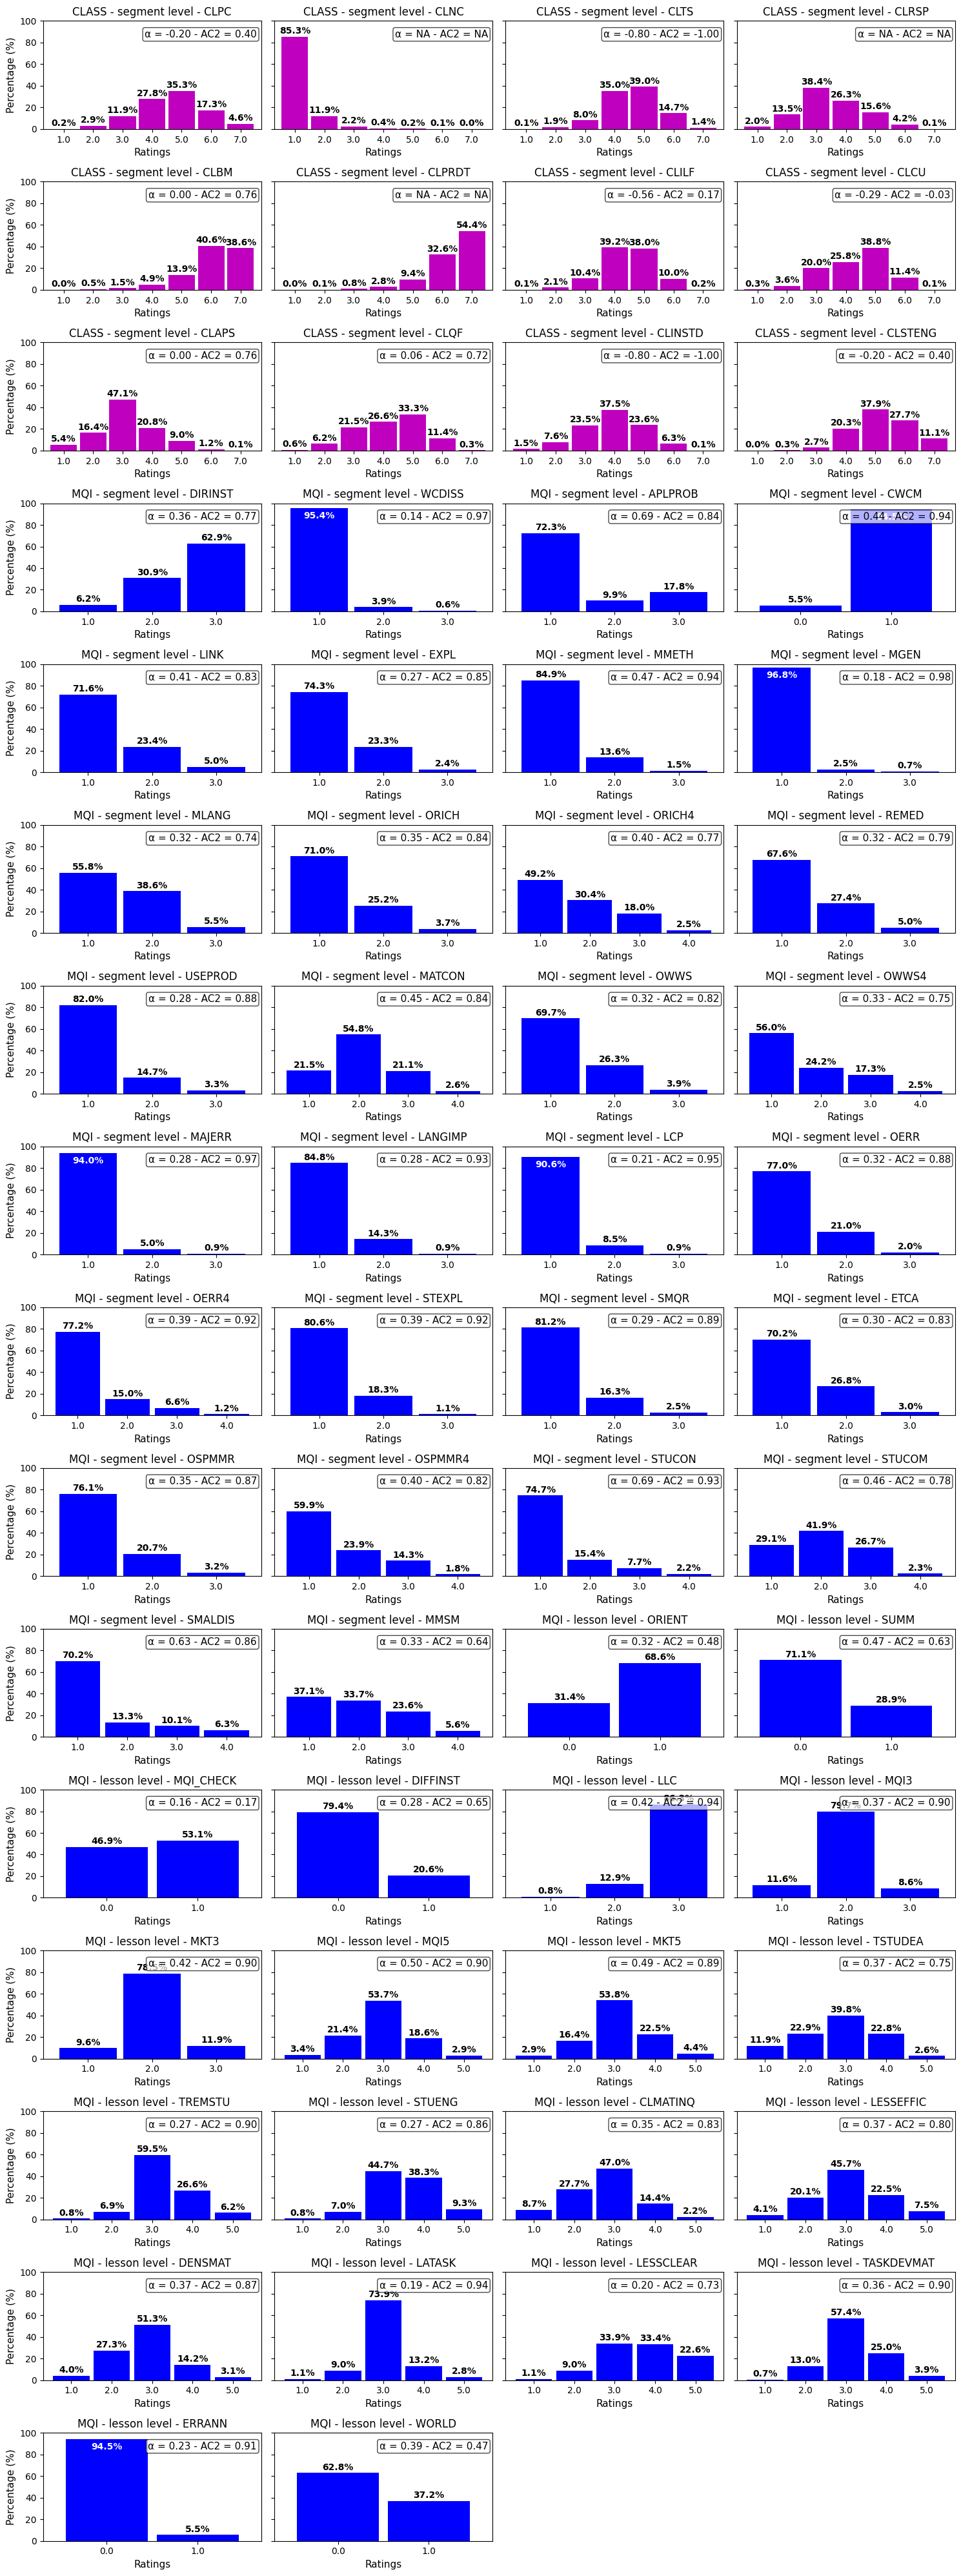

In [10]:
results_df = plot_distributions_with_alpha()

In [11]:
results_df

,variable,category,alpha,alpha_note,ac2,ac2_ci_low,ac2_ci_high,ac2_p,ac2_note,n_items_total,n_raters_total,n_items_used_ge2
0,CLPC,CLASS - segment level,-0.200000,,0.40476,0.16867,0.64085,0.008905,,5977,19,5
1,CLNC,CLASS - segment level,NaN,Only one category observed,NaN,NaN,NaN,NaN,Exception: ZeroDivisionError,5977,19,5
2,CLTS,CLASS - segment level,-0.800000,,-1.00000,-1.00000,-1.00000,0.000000,,5977,19,5
3,CLRSP,CLASS - segment level,NaN,Only one category observed,NaN,NaN,NaN,NaN,Exception: ZeroDivisionError,5977,19,5
4,CLBM,CLASS - segment level,0.000000,,0.75610,-0.05322,1.00000,0.060436,,5977,19,5
...,...,...,...,...,...,...,...,...,...,...,...,...
57,LATASK,MQI - lesson level,0.192939,,0.93870,0.92635,0.95105,0.000000,,346,36,346
58,LESSCLEAR,MQI - lesson level,0.196258,,0.72504,0.68970,0.76038,0.000000,,346,36,346
59,TASKDEVMAT,MQI - lesson level,0.357892,,0.90434,0.88942,0.91926,0.000000,,346,36,346
60,ERRANN,MQI - lesson level,0.228049,,0.90962,0.88117,0.93807,0.000000,,346,36,346


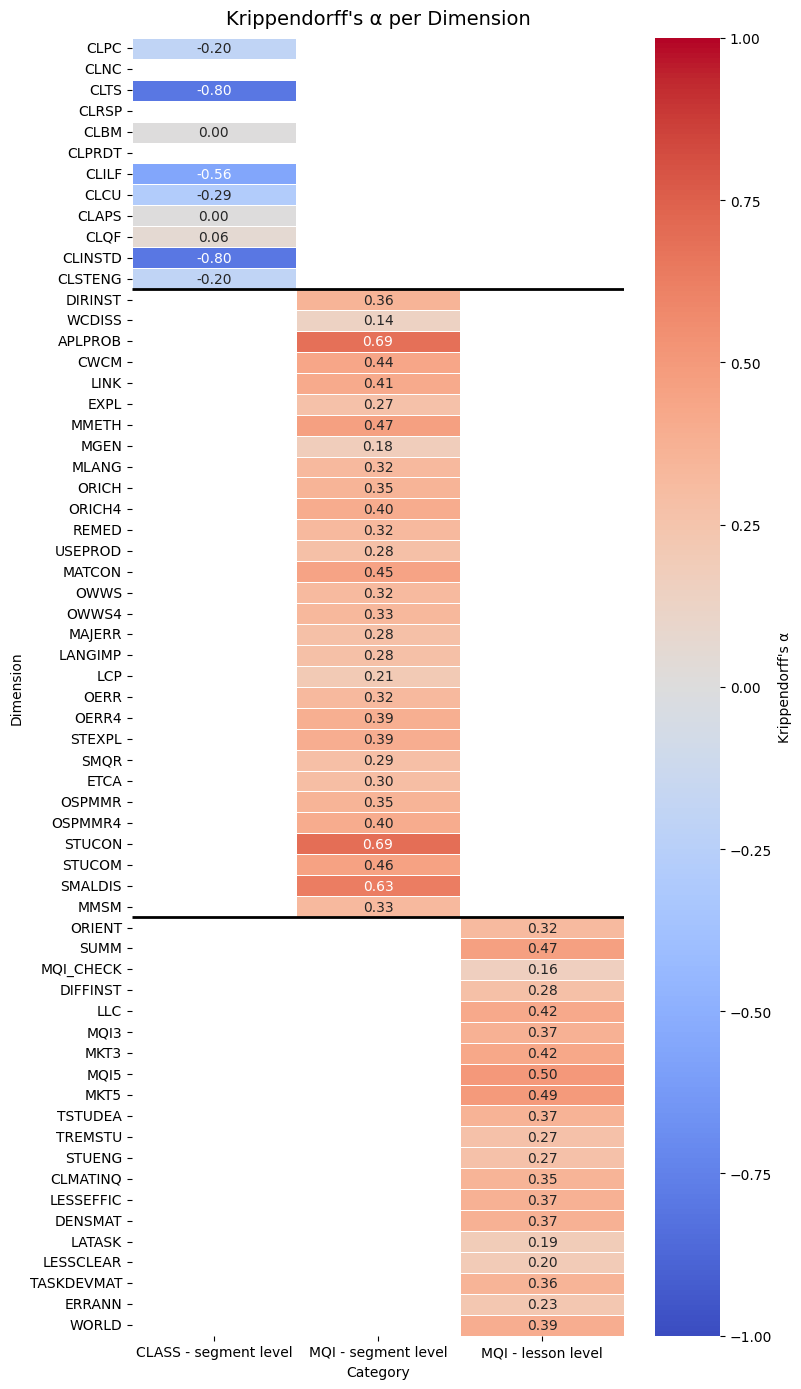

In [12]:
heatmap_alphas(results_df)

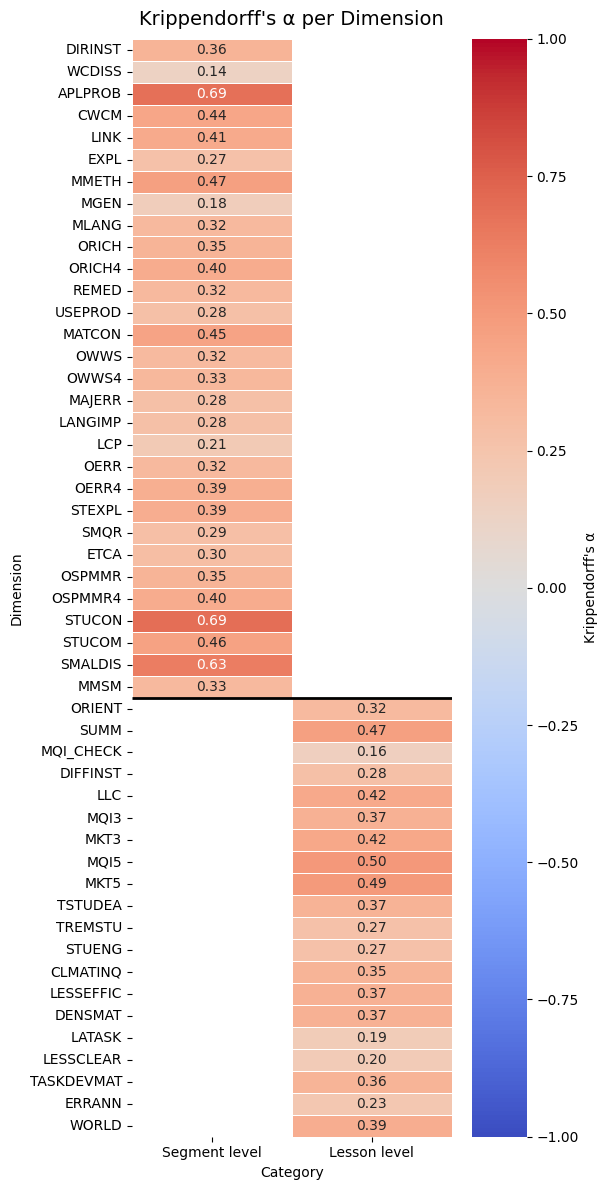

In [13]:
results_no_CLASS = results_df[~results_df["variable"].isin(vars_class)]

# Desired row order
ordered_vars = vars_mqi

# Create pivot and reindex rows to your custom order
heat_data = results_no_CLASS.pivot(index="variable", columns="category", values="alpha") 
heat_data = heat_data.reindex(ordered_vars)

# Optional: fix category column order
cat_order = ["MQI - segment level", "MQI - lesson level"]
heat_data = heat_data.reindex(columns=cat_order)
heat_data = heat_data.rename(columns={
    "MQI - segment level": "Segment level",
    "MQI - lesson level": "Lesson level"
})

plt.figure(figsize=(6, 12))
ax = sns.heatmap(
    heat_data,
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Krippendorff's α"},
    vmin=-1, vmax=1
)
plt.title("Krippendorff's α per Dimension", fontsize=14, pad=10)
plt.xlabel("Category")
plt.ylabel("Dimension")

# Draw separators between groups (chapter | lesson)
sizes = [len(vars_mqi_chapter), len(vars_mqi_lesson)]
boundaries = np.cumsum(sizes)[:-1]
for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=2)

plt.tight_layout()
plt.show()

In [14]:
# results_no_CLASS.drop(columns=["alpha_note", "ac2_p", "ac2_note"]).to_excel("appendixA_human_alpha&ac.xlsx", index=False)

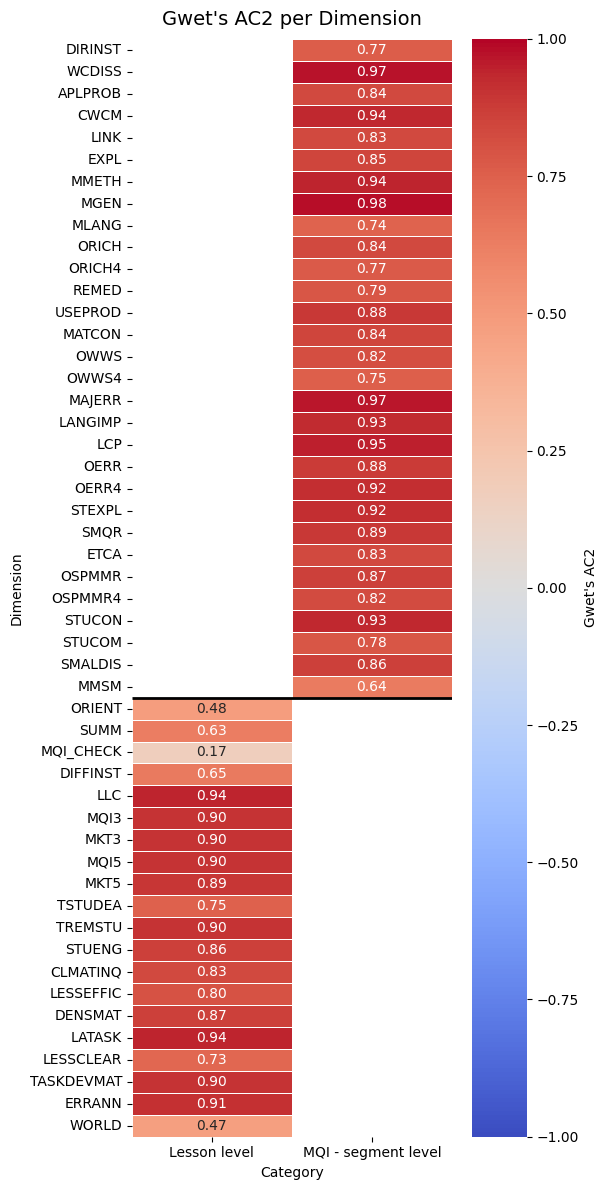

In [15]:
# Create pivot and reindex rows to your custom order
heat_data = results_no_CLASS.pivot(index="variable", columns="category", values="ac2") 
heat_data = heat_data.reindex(ordered_vars)

# Optional: fix category column order
heat_data = heat_data.rename(columns={
    "MQI - chapter level": "Segment level",
    "MQI - lesson level": "Lesson level"
})

plt.figure(figsize=(6, 12))
ax = sns.heatmap(
    heat_data,
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Gwet's AC2"},
    vmin=-1, vmax=1
)
plt.title("Gwet's AC2 per Dimension", fontsize=14, pad=10)
plt.xlabel("Category")
plt.ylabel("Dimension")

# Draw separators between groups (chapter | lesson)
sizes = [len(vars_mqi_chapter), len(vars_mqi_lesson)]
boundaries = np.cumsum(sizes)[:-1]
for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=2)

plt.tight_layout()
plt.show()

In [16]:
results_no_CLASS

,variable,category,alpha,alpha_note,ac2,ac2_ci_low,ac2_ci_high,ac2_p,ac2_note,n_items_total,n_raters_total,n_items_used_ge2
12,DIRINST,MQI - segment level,0.357188,,0.76526,0.75570,0.77481,0.000000e+00,,9716,56,9609
13,WCDISS,MQI - segment level,0.140214,,0.97088,0.96850,0.97326,0.000000e+00,,12292,63,12144
14,APLPROB,MQI - segment level,0.685273,,0.83536,0.82553,0.84519,0.000000e+00,,9716,56,9599
15,CWCM,MQI - segment level,0.436133,,0.93559,0.93071,0.94048,0.000000e+00,,12292,63,12145
16,LINK,MQI - segment level,0.412130,,0.83189,0.82483,0.83896,0.000000e+00,,12292,63,12140
17,EXPL,MQI - segment level,0.269303,,0.84959,0.84358,0.85559,0.000000e+00,,12292,63,12143
18,MMETH,MQI - segment level,0.468354,,0.94014,0.93680,0.94348,0.000000e+00,,12292,63,12148
19,MGEN,MQI - segment level,0.179407,,0.97822,0.97608,0.98036,0.000000e+00,,12292,63,12145
20,MLANG,MQI - segment level,0.323336,,0.74051,0.73254,0.74847,0.000000e+00,,12292,63,12131
21,ORICH,MQI - segment level,0.353039,,0.83545,0.82817,0.84272,0.000000e+00,,9716,56,9596


In [17]:
all_raters = set()
all_teachers = set()
all_lessons = set()
utterances_per_file = []

for var_name in results_no_CLASS["variable"]:
    category, subcat = get_category(var_name)
    df = load_dataset(var_name, category)

    # 1) Unique raters
    df_raters = df.loc[:, df.columns.str.startswith("Rater")].replace("", np.nan)
    active_raters = df_raters.columns[df_raters.notna().any()]
    all_raters.update(active_raters)

    # 2) Unique teachers
    if "NCTETID" in df.columns:
        teachers = df["NCTETID"].dropna().unique()
        all_teachers.update(teachers)

    # 3) Unique lessons
    if "OBSID" in df.columns:
        lessons = df["OBSID"].dropna().unique()
        all_lessons.update(lessons)

    # 4) Mean number of utterances per row in this df
    text_col = "full_text"
    if text_col in df.columns:
        n_utterances = (
            df[text_col]
            .fillna("")
            .astype(str)
            .str.count(r"\n") + 1
        )
        n_utterances = n_utterances[df[text_col].notna()]
        utterances_per_file.append({
            "variable": var_name,
            "mean_utterances_per_row": n_utterances.mean()
        })

In [18]:
n_unique_raters = len(all_raters)
n_unique_teachers = len(all_teachers)
n_unique_lessons = len(all_lessons)

print("Unique raters:", n_unique_raters)
print("Unique teachers:", n_unique_teachers)
print("Unique lessons:", n_unique_lessons)

Unique raters: 63
Unique teachers: 317
Unique lessons: 1658


In [19]:
utterances_summary = pd.DataFrame(utterances_per_file)
utterances_summary

,variable,mean_utterances_per_row
0,DIRINST,47.702964
1,WCDISS,47.173690
2,APLPROB,47.702964
3,CWCM,47.173690
4,LINK,47.173690
5,EXPL,47.173690
6,MMETH,47.173690
7,MGEN,47.173690
8,MLANG,47.173690
9,ORICH,47.702964


In [20]:
utt_df = pd.read_csv(r'd:\Sophie\Documents\Moi\24-25 M2 NeuroData - Padova\Thesis\NTCE\data\ncte_single_utterances.csv')
unique_values = utt_df['OBSID'].unique()
print(unique_values)

[2119 2961 2628 ... 1044  750  315]


In [22]:
set(unique_values) - set(all_lessons)

{2065, 4263}